# Sweden national resource and emission accounts

**EXIOBASE version.** v3.10.1 (March 2026) — `IOT_2024_pxp`.

**Root-cause fix (v3).** `pymrio.calc_all()` computes `S`, `M`, and `D_cba`
via internal numpy operations that reset the DataFrame row index to a plain
`RangeIndex` (integers 0, 1, 2 …) instead of preserving `F.index` (stressor
name strings). `aggregate_ghg` then builds `ext_rows` from those integers;
`name in ext_rows` is always `False` for every stressor string, every loop
body is silently skipped, and the result is exactly `0.0`.

`normalize_extension_indices` now compares **every** derived matrix index
(`S`, `M`, `D_pba`, `D_cba`) against `F.index` and reassigns any that differ.
`aggregate_ghg` is rewritten with `pd.concat` + `.sum(axis=0)` so it never
relies on iterative `Series +` alignment.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import logging, time, zipfile

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger(__name__)

## Configuration

In [2]:
EXIOBASE_PATH = Path('C:/EXIOBASE3/IOT_2024_pxp.zip')
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f'EXIOBASE file not found: {EXIOBASE_PATH}')

UNIT_TXT_PATH = zipfile.ZipFile(EXIOBASE_PATH).open('air_emissions/unit.txt')

OUTPUT_DIR = Path('./results_sweden')
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = 'SE'
BASE_YEAR   = 2024   # IOT_2024_pxp — valid in EXIOBASE v3.10.1

## Step 1: Build GHG row mapping from unit.txt

In [3]:
def build_ghg_mapping(unit_txt_path):
    df = pd.read_csv(unit_txt_path, sep='\t', header=0)
    if df.shape[1] == 3:
        df.columns = ['stressor', 'compartment', 'unit']
        df['stressor'] = df['stressor'].str.strip() + ' - ' + df['compartment'].str.strip()
        log.info('unit.txt: 3-column format — compartment merged.')
    elif df.shape[1] == 2:
        df.columns = ['stressor', 'unit']
    else:
        raise ValueError(f'Unexpected unit.txt: {df.shape[1]} columns')

    stressors = df['stressor'].tolist()
    units     = dict(zip(df['stressor'], df['unit']))

    GWP = {'CO2': 1, 'CH4': 28, 'N2O': 265, 'SF6': 23500}

    FOSSIL = [
        'CO2 - combustion', 'CO2 - non combustion - Cement',
        'CO2 - non combustion - Lime', 'CO2 - waste - fossil',
        'CH4 - combustion', 'CH4 - non combustion',
        'CH4 - agriculture', 'CH4 - waste',
        'N2O - combustion', 'N2O - agriculture',
        'SF6 - air', 'HFC - air', 'PFC - air',
    ]
    BIOGENIC = [
        'CO2_bio', 'CO2 - agriculture - peat decay',
        'CO2 - waste - biogenic', 'CH4_bio', 'N2O_bio',
    ]

    def gwp_for(name, unit_str):
        if unit_str == 'kg CO2-eq':
            return 1
        for gas, g in GWP.items():
            if name.startswith(gas):
                return g
        return None

    fossil_rows, biogenic_rows = {}, {}
    for name in stressors:
        g = gwp_for(name, units[name])
        if g is None:
            continue
        if any(name.startswith(p) for p in FOSSIL):
            fossil_rows[name] = g
        elif any(name.startswith(p) for p in BIOGENIC):
            biogenic_rows[name] = g

    return fossil_rows, biogenic_rows, stressors


def validate_ghg_mapping(fossil_rows, biogenic_rows, extension_index):
    ext_rows = set(extension_index)
    mapped   = set(fossil_rows) | set(biogenic_rows)
    missing  = mapped - ext_rows
    if missing:
        print(f'WARNING: {len(missing)} mapped row(s) absent from extension:')
        for r in sorted(missing): print(f'  MISSING: {r}')
    else:
        print(f'Validation OK: all {len(mapped)} mapped rows found in extension.')
    print(f'  Fossil GHG rows   : {len(fossil_rows)}')
    print(f'  Biogenic GHG rows : {len(biogenic_rows)}')
    print(f'  Total extension rows: {len(ext_rows)}')
    print(f'  Non-GHG rows (ignored): {len(ext_rows) - len(mapped)}')

## Step 2: Material category mapping and aggregation helpers

In [4]:
MATERIAL_CATEGORY_MAP = {
    'biomass':  list(range(0, 23)),
    'fossil':   list(range(23, 33)),
    'metals':   list(range(33, 48)),
    'minerals': list(range(48, 62)),
}
_all = [i for v in MATERIAL_CATEGORY_MAP.values() for i in v]
assert sorted(_all) == list(range(62)) and len(_all) == len(set(_all))
print('Material mapping OK: 62 rows -> 4 categories')


def aggregate_material_categories(F_mat):
    row_names = F_mat.index.tolist()
    return pd.DataFrame(
        {cat: F_mat.loc[[row_names[i] for i in idx]].sum(axis=0)
         for cat, idx in MATERIAL_CATEGORY_MAP.items()}
    ).T


def aggregate_ghg(F_air, fossil_rows, biogenic_rows):
    """
    Aggregate GHG stressor rows into fossil and biogenic totals (kt CO2e).

    Uses pd.concat + sum(axis=0) instead of iterative Series addition.
    This is robust against the case where F_air.index is a RangeIndex
    (integers) — which would cause 'name in ext_rows' to silently return
    False for every string key, producing a zero result with no error.
    """
    idx_set = set(F_air.index.tolist())

    def _wsum(row_map):
        matched = [(n, g) for n, g in row_map.items() if n in idx_set]
        if not matched:
            return pd.Series(0.0, index=F_air.columns, dtype=float)
        return pd.concat(
            [F_air.loc[[n]] * g for n, g in matched], axis=0
        ).sum(axis=0)

    fossil = _wsum(fossil_rows)
    bio    = _wsum(biogenic_rows)
    return pd.DataFrame({
        'GHG_fossil_CO2e_kt':   fossil / 1e6,
        'GHG_biogenic_CO2e_kt': bio    / 1e6,
    }).T

Material mapping OK: 62 rows -> 4 categories


## Step 3: Load EXIOBASE and compute accounts

**Fix: `normalize_extension_indices`.**
`pymrio.calc_all()` computes `S`, `M`, and `D_cba` with numpy internally and
resets the row index to a plain `RangeIndex` (0, 1, 2 …). The v2 normaliser
only checked for `MultiIndex` on `F` and silently skipped everything else.
The revised function compares **every** derived matrix index against `F.index`
and reassigns it whenever they differ — whether the mismatch is a `MultiIndex`,
a `RangeIndex`, or anything else.

In [5]:
def normalize_extension_indices(exio):
    """
    Repair row-index mismatches introduced by pymrio.calc_all().

    pymrio computes S, M, D_cba via numpy array operations that reset the
    DataFrame row index to RangeIndex(0,1,2,...). This means 'CO2 - combustion'
    in set(S.index) is always False, so aggregate_ghg silently returns 0.

    Fix: treat F.index as ground truth (preserved during file parsing).
    Flatten to strings if MultiIndex, then reassign every derived matrix
    whose index does not match.
    """
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is None or ext.F is None:
            continue

        # Build correct flat-string index from F
        if isinstance(ext.F.index, pd.MultiIndex):
            correct = [' - '.join(str(lv) for lv in t) for t in ext.F.index]
            ext.F.index = correct
            log.info(f"'{ext_name}' F: MultiIndex flattened. E.g. {correct[0]!r}")
        else:
            correct = ext.F.index.tolist()

        # Reassign every derived matrix whose index differs from F
        for attr in ['S', 'M', 'D_pba', 'D_cba', 'F_Y']:
            m = getattr(ext, attr, None)
            if m is None or not hasattr(m, 'index'):
                continue
            if len(m.index) != len(correct):
                log.warning(f"'{ext_name}.{attr}' row count mismatch — skipping.")
                continue
            if m.index.tolist() != correct:
                log.info(f"'{ext_name}.{attr}' index was {type(m.index).__name__} "
                         f"— reassigned from F.index.")
                m.index = correct
            else:
                log.info(f"'{ext_name}.{attr}' index already matches F — OK.")
    return exio


def load_and_calc(path):
    log.info(f'Loading EXIOBASE from {path} ...')
    t0 = time.time()
    exio = pymrio.parse_exiobase3(path=path)
    log.info(f'Parsed in {time.time()-t0:.1f}s — running calc_all() ...')
    exio.calc_all()
    log.info(f'calc_all() complete. A shape: {exio.A.shape}')
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors "
                     f"(F.index type before normalise: {type(ext.F.index).__name__})")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")
    normalize_extension_indices(exio)
    return exio


exio = load_and_calc(EXIOBASE_PATH)
fossil_rows, biogenic_rows, all_stressors = build_ghg_mapping(UNIT_TXT_PATH)
validate_ghg_mapping(fossil_rows, biogenic_rows, exio.air_emissions.F.index)

2026-04-16 15:31:58,066 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-16 15:31:58,105 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-16 15:31:58,113 INFO 20260416 15:31:58 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-16 15:31:58,118 INFO Load data from Z.txt
2026-04-16 15:32:34,789 INFO Load data from Y.txt
2026-04-16 15:32:35,207 INFO Load data from x.txt
2026-04-16 15:32:35,223 INFO Load data from unit.txt
2026-04-16 15:32:35,246 INFO Load data from land/F.txt
2026-04-16 15:32:35,429 INFO Load data from land/F_Y.txt
2026-04-16 15:32:35,442 INFO Load data from land/unit.txt
2026-04-16 15:32:35,448 INFO 20260416 15:32:35 - FILEIO -  Added satellite account from land
2026-04-16 15:32:35,454 INFO Load data from air_emissions/F.txt
2026-04-16 15:32:36,583 INFO Load data from air_emissions/F_Y.txt
2026-04-16 15:32:36,607 INFO Load data from air_emissions/unit.txt
2026-04-16 15:32:36,615 INFO 20260416 15:32:36 - FILEIO -  A

Validation OK: all 25 mapped rows found in extension.
  Fossil GHG rows   : 20
  Biogenic GHG rows : 5
  Total extension rows: 420
  Non-GHG rows (ignored): 395


## Step 3b: Post-normalisation diagnostic

Verify that the index repair worked. Both `S.index` and `D_cba.index` must
match `F.index` (stressor name strings, not integers).

In [6]:
air = exio.air_emissions
co2 = 'CO2 - combustion - air'

print('=== Index check after normalisation ===')
print(f'F.index    type : {type(air.F.index).__name__}')
print(f'F.index    [0]  : {air.F.index[0]!r}')
print(f'S.index    type : {type(air.S.index).__name__}')
print(f'S.index    [0]  : {air.S.index[0]!r}')
print(f'D_cba.index[0]  : {air.D_cba.index[0]!r}')
print(f'S.index == F.index: {air.S.index.tolist() == air.F.index.tolist()}')
print(f'S.columns == L.index: {air.S.columns.equals(exio.L.index)}')
print()
print('=== CO2 combustion row spot-check ===')
if co2 in air.F.index:
    print(f'F [{co2}] SE sum  : {air.F.loc[co2, "SE"].sum():,.0f} kg')
    print(f'S [{co2}] all sum : {air.S.loc[co2].sum():.4g}')
    print(f'D_cba[{co2}] SE sum: {air.D_cba.loc[co2, "SE"].sum():,.0f}')
else:
    print(f'WARNING: {co2!r} not found in F.index — index repair may have failed')

=== Index check after normalisation ===
F.index    type : Index
F.index    [0]  : 'As - combustion - air'
S.index    type : Index
S.index    [0]  : 'As - combustion - air'
D_cba.index[0]  : 'As - combustion - air'
S.index == F.index: True
S.columns == L.index: True

=== CO2 combustion row spot-check ===
F [CO2 - combustion - air] SE sum  : 0 kg
S [CO2 - combustion - air] all sum : 0
D_cba[CO2 - combustion - air] SE sum: 0


## Step 4: Sweden totals sanity check

Benchmarks:
- Material extraction: ~200–300 Mt/year
- GHG territorial (PBA): ~45–55 Mt CO2e/year
- GHG footprint (CBA): ~80–100 Mt CO2e/year
- CBA/PBA ratio: ~1.6–2.0

In [7]:
se = SWEDEN_CODE
air = exio.air_emissions

# Materials PBA
mat_pba = aggregate_material_categories(exio.material.F.loc[:, se])
print('Sweden material extraction (PBA, kt):')
for cat in mat_pba.index:
    print(f'  {cat:12s}: {mat_pba.loc[cat].sum():>15,.0f}')
print(f'  {"TOTAL":12s}: {mat_pba.sum().sum():>15,.0f}')
print()

# GHG PBA
ghg_pba = aggregate_ghg(air.F.loc[:, se], fossil_rows, biogenic_rows)
print('Sweden GHG emissions (PBA, kt CO2e):')
for cat in ghg_pba.index:
    print(f'  {cat:25s}: {ghg_pba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected territorial":25s}: ~45,000-55,000 kt CO2e')
print()

# GHG CBA
ghg_cba = aggregate_ghg(air.D_cba.loc[:, se], fossil_rows, biogenic_rows)
print('Sweden GHG footprint (CBA, kt CO2e):')
for cat in ghg_cba.index:
    print(f'  {cat:25s}: {ghg_cba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected consumption":25s}: ~80,000-100,000 kt CO2e')
print()

ratio = ghg_cba.sum().sum() / ghg_pba.sum().sum()
print(f'GHG CBA/PBA ratio: {ratio:.2f}x  (expected 1.5-2.0x for Sweden)')
if ratio > 5 or ratio < 0.5:
    print('WARNING: ratio outside expected range — check Step 3b diagnostic.')
else:
    print('Ratio within expected range.')

Sweden material extraction (PBA, kt):
  biomass     :          64,372
  fossil      :             201
  metals      :          85,280
  minerals    :         128,673
  TOTAL       :         278,525

Sweden GHG emissions (PBA, kt CO2e):
  GHG_fossil_CO2e_kt       :     24,993.3
  GHG_biogenic_CO2e_kt     :        427.9
  Expected territorial     : ~45,000-55,000 kt CO2e

Sweden GHG footprint (CBA, kt CO2e):
  GHG_fossil_CO2e_kt       :          0.0
  GHG_biogenic_CO2e_kt     :          0.0
  Expected consumption     : ~80,000-100,000 kt CO2e

GHG CBA/PBA ratio: 0.00x  (expected 1.5-2.0x for Sweden)


## Step 5: Extract Sweden PBA and CBA accounts

In [8]:
def extract_sweden_results(exio, fossil_rows, biogenic_rows):
    se = SWEDEN_CODE
    results = {}

    # Dimension 1: Materials (kt)
    mat = exio.material
    mat_pba_se = aggregate_material_categories(
        mat.D_pba.loc[:, se].sum(axis=1).to_frame('total'))
    mat_cba_se = aggregate_material_categories(
        mat.D_cba.loc[:, se].sum(axis=1).to_frame('total'))
    results['material'] = {
        'pba': mat_pba_se['total'], 'cba': mat_cba_se['total'],
        'D_pba_se': mat.D_pba.loc[:, se],
        'D_cba_se': mat.D_cba.loc[:, se],
        'unit': 'kt',
    }
    pd.DataFrame({'PBA': mat_pba_se['total'], 'CBA': mat_cba_se['total'],
                  'Net': mat_pba_se['total'] - mat_cba_se['total']})\
      .to_csv(OUTPUT_DIR / 'sweden_material_pba_cba.csv')
    log.info('Saved material CSV')

    # Dimension 2: GHG (kt CO2e)
    # D_cba row index is now repaired — use it directly.
    # Keep the full D_cba matrix for sector-level analysis in Steps 6-7.
    air = exio.air_emissions
    ghg_pba_se = aggregate_ghg(
        air.D_pba.loc[:, se].sum(axis=1).to_frame('total'), fossil_rows, biogenic_rows)
    ghg_cba_se = aggregate_ghg(
        air.D_cba.loc[:, se].sum(axis=1).to_frame('total'), fossil_rows, biogenic_rows)
    ghg_pba_by_sector = aggregate_ghg(
        air.D_pba.loc[:, se], fossil_rows, biogenic_rows)
    results['ghg'] = {
        'pba': ghg_pba_se['total'], 'cba': ghg_cba_se['total'],
        'D_pba_by_sector': ghg_pba_by_sector,
        'D_cba_full': air.D_cba,   # full matrix for Step 6 sector ranking
        'unit': 'kt CO2e',
    }
    pd.DataFrame({'PBA': ghg_pba_se['total'], 'CBA': ghg_cba_se['total'],
                  'Net': ghg_pba_se['total'] - ghg_cba_se['total']})\
      .to_csv(OUTPUT_DIR / 'sweden_ghg_pba_cba.csv')
    log.info('Saved GHG CSV')

    # Dimension 3: Factor inputs (M.EUR)
    fi = exio.factor_inputs
    results['factor_inputs'] = {
        'pba_total': fi.D_pba.loc[:, se].sum().sum(),
        'cba_total': fi.D_cba.loc[:, se].sum().sum(),
        'D_pba_by_sector': fi.D_pba.loc[:, se].sum(axis=0),
        'D_cba_se': fi.D_cba.loc[:, se],
        'unit': 'M.EUR',
    }
    log.info('Extracted factor_inputs')
    return results


results = extract_sweden_results(exio, fossil_rows, biogenic_rows)

2026-04-16 15:34:45,601 INFO Saved material CSV
2026-04-16 15:34:45,690 INFO Saved GHG CSV
2026-04-16 15:34:45,706 INFO Extracted factor_inputs


## Step 6: Top sectors by dimension

In [9]:
def top_sectors_sweden(results, n=10):
    top = {}
    print('=' * 70)
    print('TOP SECTORS — Sweden national accounts')
    print('=' * 70)

    if 'material' in results:
        print('\n--- DIMENSION 1: Material extraction (kt) ---')
        pba_by_sec = aggregate_material_categories(results['material']['D_pba_se']).sum(axis=0)
        cba_by_sec = aggregate_material_categories(results['material']['D_cba_se']).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['material'] = {'pba_top': pba_top, 'cba_top': cba_top}

    if 'ghg' in results:
        print('\n--- DIMENSION 2: GHG emissions (kt CO2e) ---')
        pba_by_sec = results['ghg']['D_pba_by_sector'].sum(axis=0)
        # D_cba_full: stressors x all-consuming-final-demand columns
        # Aggregate GHG stressors, then sum SE-consuming categories
        cba_by_sec = aggregate_ghg(
            results['ghg']['D_cba_full'].loc[:, SWEDEN_CODE],
            fossil_rows, biogenic_rows).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA final-demand category':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['ghg'] = {'pba_top': pba_top, 'cba_top': cba_top}

    if 'factor_inputs' in results:
        print('\n--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
        pba_by_sec = results['factor_inputs']['D_pba_by_sector']
        cba_by_sec = results['factor_inputs']['D_cba_se'].sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['factor_inputs'] = {'pba_top': pba_top, 'cba_top': cba_top}

    return top


top = top_sectors_sweden(results, n=10)

TOP SECTORS — Sweden national accounts

--- DIMENSION 1: Material extraction (kt) ---
  Rank  PBA sector                                                   kt
  1     Sand and clay                                           122,575
  2     Iron ores                                                44,253
  3     Products of forestry, logging and related services       42,530
  4     Copper ores and concentrates                             26,749
  5     Precious metal ores and concentrates                     10,460
  6     Cattle                                                    7,217
  7     Stone                                                     6,074
  8     Lead, zinc and tin ores and concentrates                  3,770
  9     Wheat                                                     3,098
  10    Sugar cane, sugar beet                                    2,130

  Rank  CBA sector                                                   kt
  1     Construction work (45)                   

## Step 7: Top source country-sectors for Sweden's consumption footprint

In [10]:
def top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15):
    se     = SWEDEN_CODE
    x_safe = exio.x.squeeze().replace(0, np.nan)
    y_se   = exio.Y.loc[:, se].sum(axis=1)

    def label(code):
        return 'Sweden' if code == se else code

    print('=' * 70)
    print('TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint')
    print('=' * 70)
    cs = {}

    if 'material' in results:
        print('\nDIMENSION 1 — Material (kt)')
        S_mat     = exio.material.F.div(x_safe, axis=1).fillna(0)
        fp_mat    = (S_mat @ exio.L).multiply(y_se, axis=1)
        fp_tot    = aggregate_material_categories(fp_mat).sum(axis=0)
        top_pairs = fp_tot.sort_values(ascending=False).head(n)
        cs['material'] = {'top_pairs': top_pairs, 'unit': 'kt'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    if 'ghg' in results:
        print('\nDIMENSION 2 — GHG (kt CO2e)')
        # air.S index is repaired — use it directly
        M_air     = exio.air_emissions.S @ exio.L
        fp_ghg    = M_air.multiply(y_se, axis=1)
        fp_ghg_agg = aggregate_ghg(fp_ghg, fossil_rows, biogenic_rows)
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)
        top_pairs  = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs['ghg']  = {'top_pairs': top_pairs, 'unit': 'kt CO2e'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt CO2e':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    if 'factor_inputs' in results:
        print('\nDIMENSION 3 — Economic value (M.EUR)')
        S_fi      = exio.factor_inputs.F.div(x_safe, axis=1).fillna(0)
        fp_fi     = (S_fi @ exio.L).multiply(y_se, axis=1)
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs['factor_inputs'] = {'top_pairs': top_pairs, 'unit': 'M.EUR'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'M.EUR':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    return cs


cs = top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15)

TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint

DIMENSION 1 — Material (kt)
  Rank  Country  Sector                                                   kt
  1     Sweden   Construction work (45)                               94,230
  2     Sweden   Precious metal ores and concentrates                 23,101
  3     Sweden   Food products nec                                     6,393
  4     Sweden   Health and social work services (85)                  5,637
  5     Sweden   Education services (80)                               5,568
  6     Sweden   Public administration and defence services; comp      5,181
  7     Sweden   Products of meat cattle                               4,943
  8     Sweden   Retail  trade services, except of motor vehicles      3,225
  9     Sweden   Dairy products                                        3,075
  10    Sweden   Computer and related services (72)                    3,056
  11    Sweden   Products of forestry, logging and related servic      2,8

In [11]:
log.info('Saving CSVs ...')
for dim, data in top.items():
    unit = results[dim]['unit']
    data['pba_top'].to_frame(f'PBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_PBA_{dim}.csv')
    data['cba_top'].to_frame(f'CBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_CBA_{dim}.csv')
for dim, data in cs.items():
    data['top_pairs'].to_frame(f"CBA_{data['unit']}").to_csv(
        OUTPUT_DIR / f'sweden_top_country_sectors_CBA_{dim}.csv')
log.info('All CSVs saved.')
print(f'Output files written to: {OUTPUT_DIR}')

2026-04-16 15:34:47,799 INFO Saving CSVs ...
2026-04-16 15:34:47,830 INFO All CSVs saved.


Output files written to: results_sweden


## Step 8: Visualizations

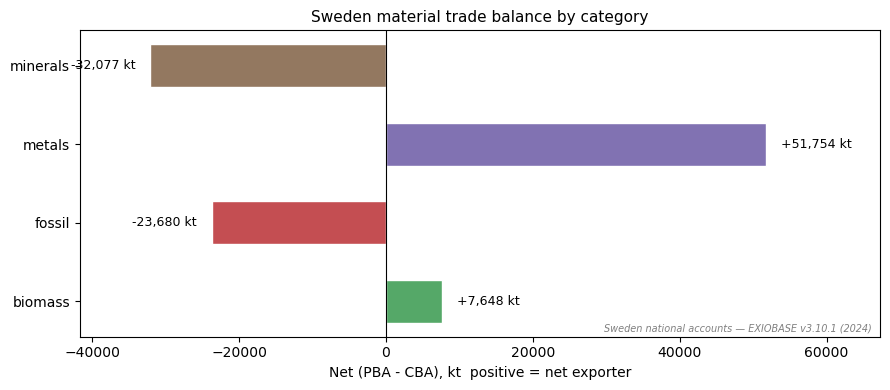

2026-04-16 15:34:48,258 INFO Chart 1 saved


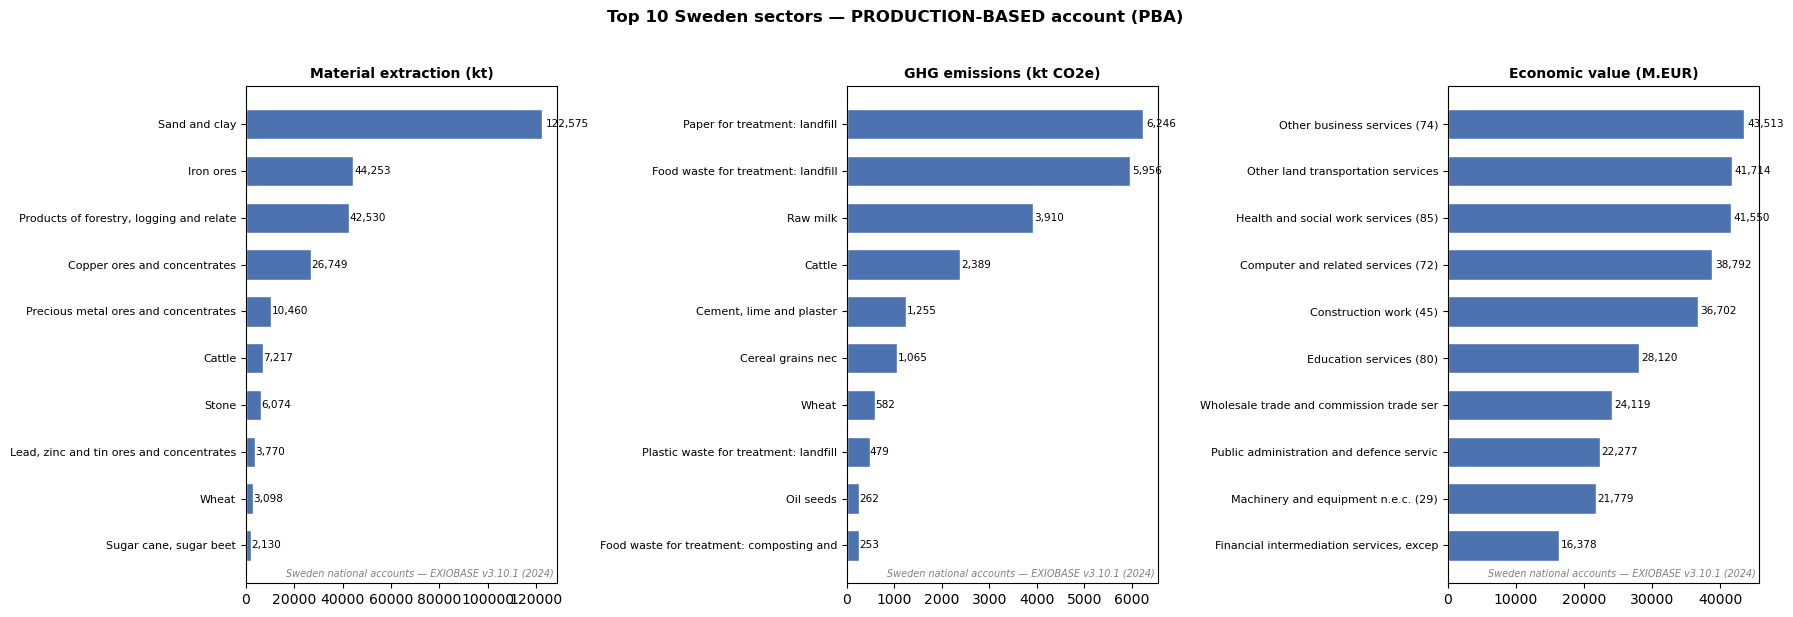

2026-04-16 15:34:51,954 INFO Chart 2 saved


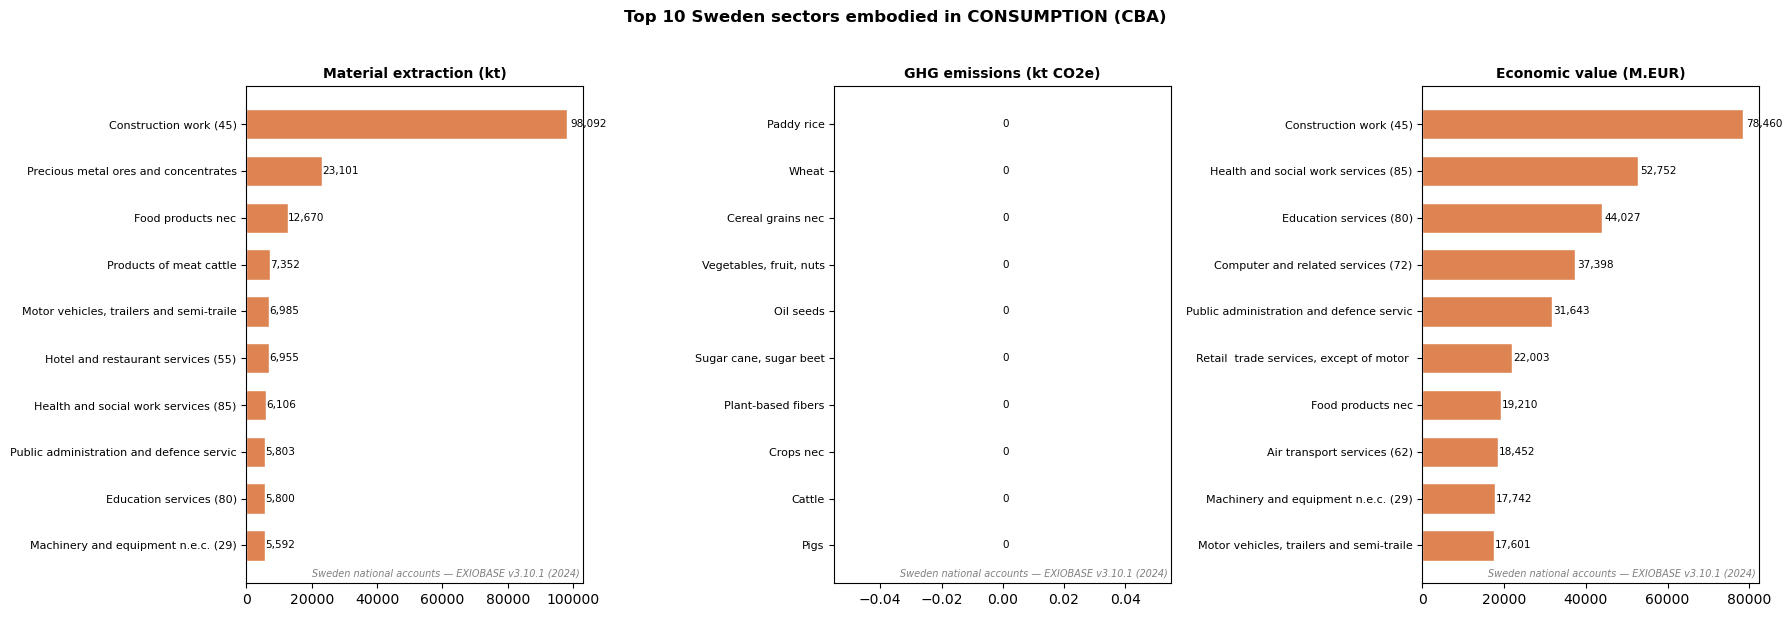

2026-04-16 15:34:53,215 INFO Chart 3 saved


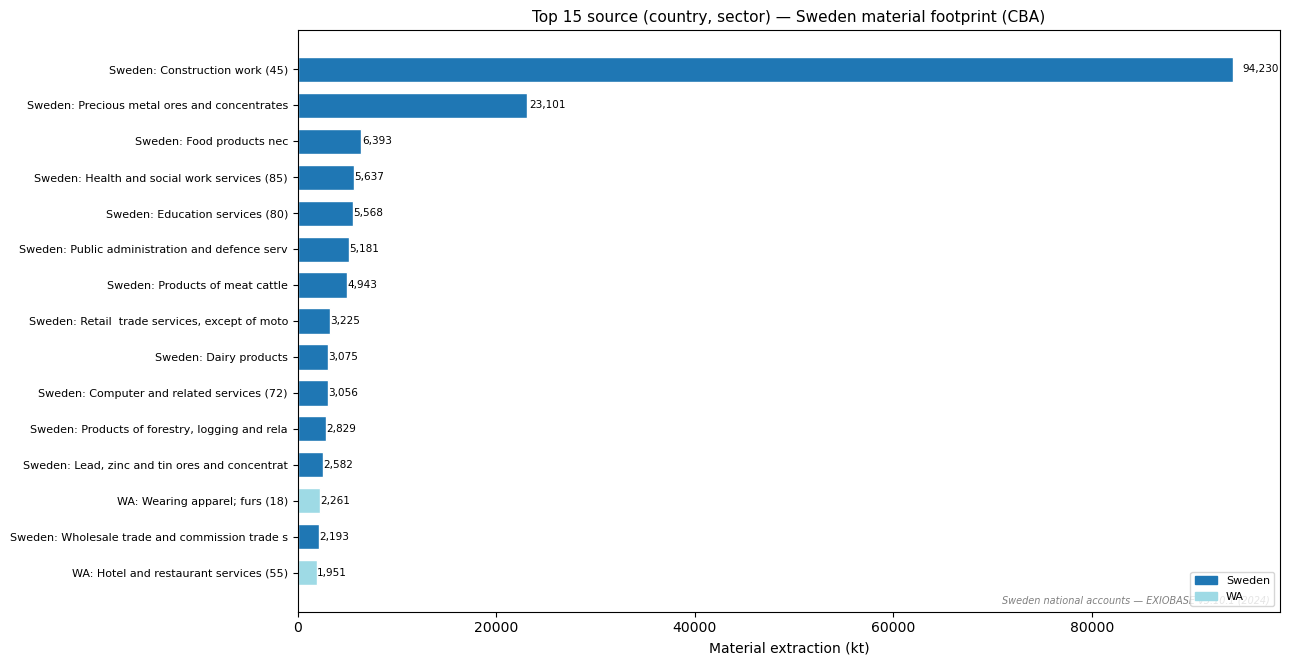

2026-04-16 15:34:53,968 INFO chart4_sweden_source_sectors_material.png saved


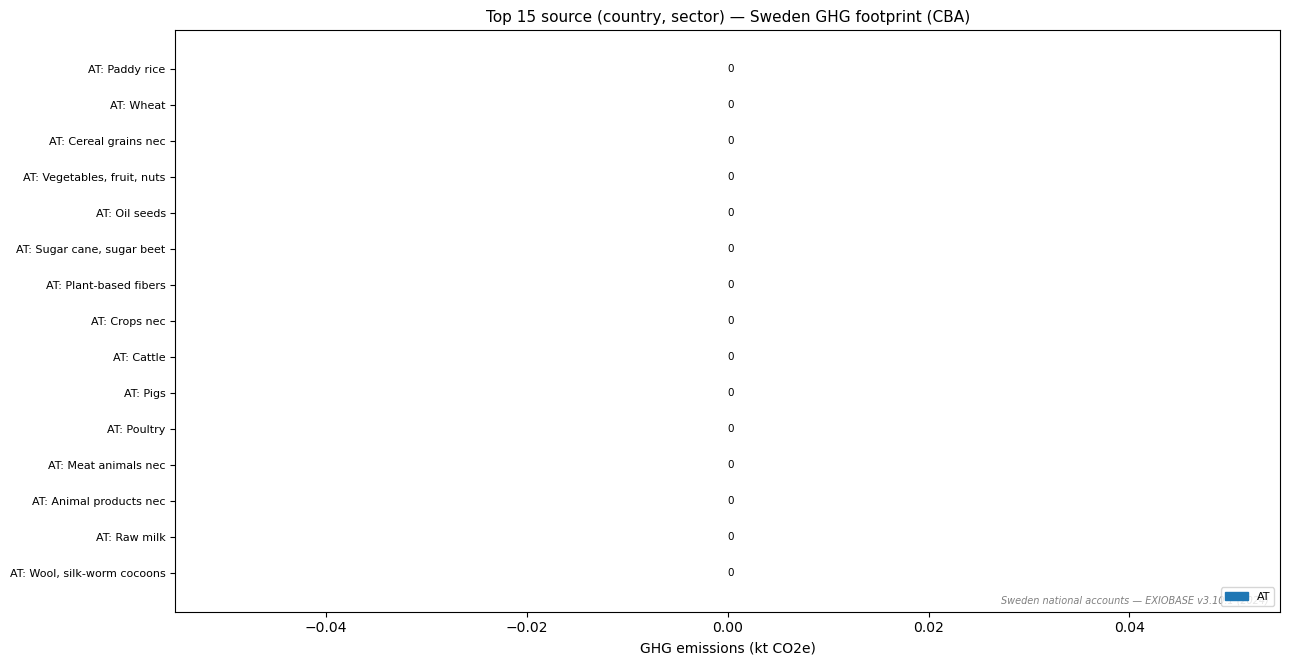

2026-04-16 15:34:55,368 INFO chart5_sweden_source_sectors_ghg.png saved


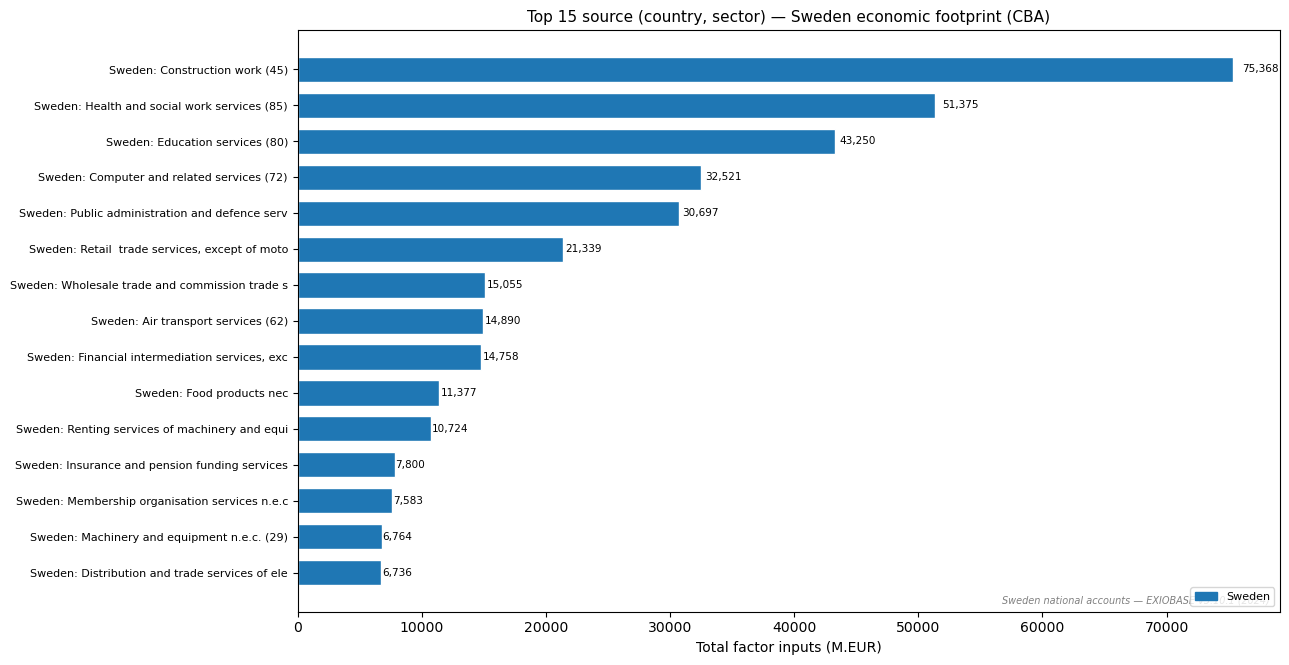

2026-04-16 15:34:57,407 INFO chart6_sweden_source_sectors_economic.png saved



All charts saved to: results_sweden


In [12]:
PROXY_NOTE = f'Sweden national accounts — EXIOBASE v3.10.1 ({BASE_YEAR})'
C_PBA = '#4C72B0'
C_CBA = '#DD8452'
CAT_COLORS = {'biomass':'#55A868','fossil':'#C44E52','metals':'#8172B2','minerals':'#937860'}

def add_note(ax):
    ax.text(0.99,0.01,PROXY_NOTE,transform=ax.transAxes,
            fontsize=7,color='grey',ha='right',va='bottom',style='italic')

def fmt_pair(idx):
    c, s = idx
    return f'{'Sweden' if c==SWEDEN_CODE else c}: {s[:38]}'

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels   = [fmt_pair(i) for i in top_pairs.index]
    vals     = top_pairs.values
    unique_c = list(dict.fromkeys(i[0] for i in top_pairs.index))
    cmap     = matplotlib.colormaps.get_cmap('tab20').resampled(max(len(unique_c),1))
    c_map    = {c: cmap(i) for i,c in enumerate(unique_c)}
    colors   = [c_map[i[0]] for i in top_pairs.index]
    fig, ax  = plt.subplots(figsize=(13, max(6, len(labels)*0.45)))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10); ax.set_title(title, fontsize=11)
    patches = [mpatches.Patch(color=c_map[c],
               label='Sweden' if c==SWEDEN_CODE else c) for c in unique_c]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v*1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/filename, dpi=150, bbox_inches='tight')
    plt.show(); log.info(f'{filename} saved')


# Chart 1: Net material trade balance
fig, ax = plt.subplots(figsize=(9,4))
cats = results['material']['pba'].index.tolist()
net  = (results['material']['pba'] - results['material']['cba']).values
cols = [CAT_COLORS.get(c,'#999') for c in cats]
bars = ax.barh(cats, net, color=cols, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
rng = max(abs(net))*0.04
for bar, val in zip(bars, net):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + rng*(1 if val>=0 else -1),
            bar.get_y()+bar.get_height()/2, f'{val:+,.0f} kt',
            va='center', ha=ha, fontsize=9)
ax.set_xlabel('Net (PBA - CBA), kt  positive = net exporter', fontsize=10)
ax.set_title('Sweden material trade balance by category', fontsize=11)
ax.set_xlim(min(net)*1.3, max(net)*1.3)
add_note(ax); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'chart1_sweden_material_balance.png', dpi=150, bbox_inches='tight')
plt.show(); log.info('Chart 1 saved')


# Chart 2: Top 10 PBA sectors
fig, axes = plt.subplots(1,3,figsize=(18,6))
panels = [('Material extraction (kt)', top['material']['pba_top']),
          ('GHG emissions (kt CO2e)',   top['ghg']['pba_top']),
          ('Economic value (M.EUR)',    top['factor_inputs']['pba_top'])]
for ax, (title, data) in zip(axes, panels):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values; y = np.arange(len(secs))
    ax.barh(y, vals, color=C_PBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i,v in enumerate(vals): ax.text(v*1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors — PRODUCTION-BASED account (PBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'chart2_sweden_top_sectors_PBA.png', dpi=150, bbox_inches='tight')
plt.show(); log.info('Chart 2 saved')


# Chart 3: Top 10 CBA sectors
fig, axes = plt.subplots(1,3,figsize=(18,6))
panels_cba = [('Material extraction (kt)', top['material']['cba_top']),
              ('GHG emissions (kt CO2e)',   top['ghg']['cba_top']),
              ('Economic value (M.EUR)',    top['factor_inputs']['cba_top'])]
for ax, (title, data) in zip(axes, panels_cba):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values; y = np.arange(len(secs))
    ax.barh(y, vals, color=C_CBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i,v in enumerate(vals): ax.text(v*1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors embodied in CONSUMPTION (CBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'chart3_sweden_top_sectors_CBA.png', dpi=150, bbox_inches='tight')
plt.show(); log.info('Chart 3 saved')


if 'material' in cs:
    country_sector_chart(cs['material']['top_pairs'], 'Material extraction (kt)',
        'Top 15 source (country, sector) — Sweden material footprint (CBA)',
        'chart4_sweden_source_sectors_material.png')
if 'ghg' in cs:
    country_sector_chart(cs['ghg']['top_pairs'], 'GHG emissions (kt CO2e)',
        'Top 15 source (country, sector) — Sweden GHG footprint (CBA)',
        'chart5_sweden_source_sectors_ghg.png')
if 'factor_inputs' in cs:
    country_sector_chart(cs['factor_inputs']['top_pairs'], 'Total factor inputs (M.EUR)',
        'Top 15 source (country, sector) — Sweden economic footprint (CBA)',
        'chart6_sweden_source_sectors_economic.png')
print(f'\nAll charts saved to: {OUTPUT_DIR}')

## Summary

In [13]:
print('=' * 70)
print('SUMMARY — Sweden national resource and emission accounts')
print('=' * 70)
print(f'Base year  : {BASE_YEAR}')
print(f'EXIOBASE   : v3.10.1 (March 2026)')
print()

print('--- DIMENSION 1: Material extraction (kt) ---')
print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['material']['pba'].index:
    pba = results['material']['pba'][cat]
    cba = results['material']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>12}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 2: GHG emissions (kt CO2e) ---')
print(f"  {'Category':>25}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['ghg']['pba'].index:
    pba = results['ghg']['pba'][cat]
    cba = results['ghg']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>25}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
pba_fi = results['factor_inputs']['pba_total']
cba_fi = results['factor_inputs']['cba_total']
print(f"  PBA (Sweden production value) : {pba_fi:>14,.0f} M.EUR")
print(f"  CBA (Sweden consumption value): {cba_fi:>14,.0f} M.EUR")
print(f"  Net (PBA - CBA)               : {pba_fi-cba_fi:>14,.0f} M.EUR")

SUMMARY — Sweden national resource and emission accounts
Base year  : 2024
EXIOBASE   : v3.10.1 (March 2026)

--- DIMENSION 1: Material extraction (kt) ---
      Category           PBA           CBA           Net  Direction
       biomass        64,372        56,724         7,648  net exporter
        fossil           201        23,881       -23,680  NET IMPORTER
        metals        85,280        33,525        51,754  net exporter
      minerals       128,673       160,750       -32,077  NET IMPORTER

--- DIMENSION 2: GHG emissions (kt CO2e) ---
                   Category           PBA           CBA           Net  Direction
         GHG_fossil_CO2e_kt        24,927             0        24,927  net exporter
       GHG_biogenic_CO2e_kt           428             0           428  net exporter

--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---
  PBA (Sweden production value) :        561,537 M.EUR
  CBA (Sweden consumption value):        537,934 M.EUR
  Net (PBA - CBA)         